# Домашнее задание к семинарам 08-09 (HW08-09)

Тема: PyTorch 101 b основы оптимизации обучения.
Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping).
Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

In [1]:
# ШАГ 1. Импорты
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ШАГ 2. Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ШАГ 3. Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ШАГ 4. Пути к папкам и артефактам
BASE_DIR = Path(".") 
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = BASE_DIR / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

Device: cpu


In [2]:
# ШАГ 5. Определяем transform для EMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ШАГ 6. Загружаем train/test части EMNIST balanced через torchvision
train_dataset_full = datasets.EMNIST(
    root=DATA_DIR,
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root=DATA_DIR,
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

print("Train full size:", len(train_dataset_full))
print("Test size:", len(test_dataset))
print("Number of classes:", len(train_dataset_full.classes))

100%|██████████| 562M/562M [01:52<00:00, 5.00MB/s] 


Train full size: 112800
Test size: 18800
Number of classes: 47


In [3]:
# ШАГ 7. Делаем воспроизводимое разбиение train/val из train-части
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 90240
Val size: 22560
Test size: 18800


In [4]:
# ШАГ 8. Создаём DataLoader для train / val / test
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully")

DataLoaders created successfully


In [5]:
# ШАГ 9. Sanity-check: смотрим shapes и диапазоны значений
x_batch, y_batch = next(iter(train_loader))

print("x_batch.shape:", x_batch.shape)   # [batch, channels, height, width]
print("y_batch.shape:", y_batch.shape)   # [batch]
print("x_batch min:", x_batch.min().item())
print("x_batch max:", x_batch.max().item())
print("y_batch[:10]:", y_batch[:10])

# ШАГ 10. Проверяем, что батчи можно перевести на тот же device, что и модель
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

print("x_batch device:", x_batch.device)
print("y_batch device:", y_batch.device)

x_batch.shape: torch.Size([128, 1, 28, 28])
y_batch.shape: torch.Size([128])
x_batch min: -1.0
x_batch max: 1.0
y_batch[:10]: tensor([32,  3, 36, 29, 28, 23, 39,  2,  9, 10])
x_batch device: cpu
y_batch device: cpu


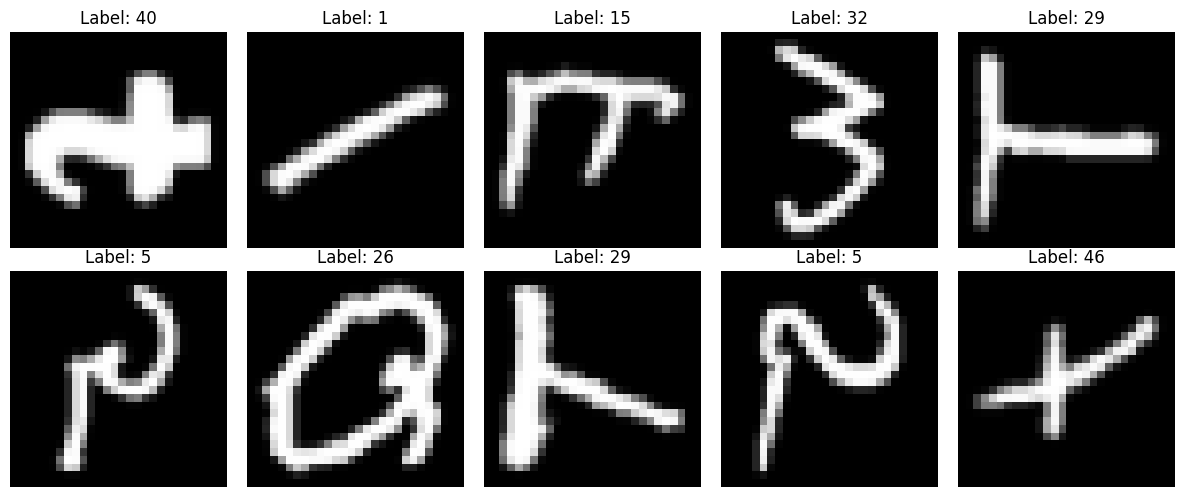

In [6]:
# ШАГ 11. Показываем несколько изображений из train-датасета
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    img, label = train_dataset[i]
    img = img.squeeze(0).numpy()
    img = img * 0.5 + 0.5  # денормализация
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# ШАГ 12. Реализуем MLP как nn.Module
class MLP(nn.Module):
    def __init__(self, input_dim=28*28, num_classes=47, hidden_sizes=[512, 256],
                 dropout=0.0, use_batchnorm=False):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_sizes:

            layers.append(nn.Linear(prev_dim, hidden_dim))


            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))


            layers.append(nn.ReLU())


            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim


        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # ШАГ 12.1 Flatten изображения
        x = self.flatten(x)

        # ШАГ 12.2 Проход через сеть
        logits = self.net(x)
        return logits


# Проверка, что модель создаётся
model = MLP()
model = model.to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=47, bias=True)
  )
)


In [8]:
# ШАГ 13. Функция расчёта accuracy
def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total

In [9]:
# ШАГ 14. Функция обучения одной эпохи
def train_one_epoch(model, loader, criterion, optimizer, device):
    # ШАГ 14.1 Переводим модель в режим train
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in loader:
        # ШАГ 14.2 Переводим батч на тот же device
        x = x.to(device)
        y = y.to(device)

        # ШАГ 14.3 Обнуляем градиенты
        optimizer.zero_grad()

        # ШАГ 14.4 Прямой проход
        logits = model(x)

        # ШАГ 14.5 Считаем loss
        loss = criterion(logits, y)

        # ШАГ 14.6 Обратное распространение
        loss.backward()

        # ШАГ 14.7 Шаг оптимизатора
        optimizer.step()

        # ШАГ 14.8 Накопление статистики
        running_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [10]:
# ШАГ 15. Функция оценки на val/test
def evaluate(model, loader, criterion, device):
    # ШАГ 15.1 Переводим модель в режим eval
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    # ШАГ 15.2 Отключаем вычисление градиентов
    with torch.no_grad():
        for x, y in loader:
            # ШАГ 15.3 Переводим батч на тот же device
            x = x.to(device)
            y = y.to(device)

            # ШАГ 15.4 Прямой проход
            logits = model(x)

            # ШАГ 15.5 Считаем loss
            loss = criterion(logits, y)

            # ШАГ 15.6 Накопление статистики
            running_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            running_correct += (preds == y).sum().item()
            running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [11]:
# ШАГ 16. Универсальная функция запуска эксперимента
def run_experiment(
    experiment_id,
    hidden_sizes,
    dropout,
    use_batchnorm,
    optimizer_name,
    lr,
    weight_decay=0.0,
    momentum=0.0,
    epochs=10,
    early_stopping=False,
    patience=4
):
    # ШАГ 16.1 Создаём модель
    model = MLP(
        input_dim=28*28,
        num_classes=47,
        hidden_sizes=hidden_sizes,
        dropout=dropout,
        use_batchnorm=use_batchnorm
    ).to(device)

    # ШАГ 16.2 Определяем loss
    criterion = nn.CrossEntropyLoss()

    # ШАГ 16.3 Определяем optimizer
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    # ШАГ 16.4 История обучения
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # ШАГ 16.5 Переменные для лучшей модели
    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state_dict = None
    best_epoch = 0

    # ШАГ 16.6 Счётчик для EarlyStopping
    epochs_without_improvement = 0

    # ШАГ 16.7 Цикл по эпохам
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{experiment_id}] Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

        # ШАГ 16.8 Обновляем лучшую модель по val_accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # ШАГ 16.9 EarlyStopping, если включён
        if early_stopping and epochs_without_improvement >= patience:
            print(f"[{experiment_id}] Early stopping triggered at epoch {epoch}")
            break

    # ШАГ 16.10 Возвращаем результат эксперимента
    result = {
        "experiment_id": experiment_id,
        "dataset": "EMNIST",
        "seed": SEED,
        "model_summary": f"hidden={hidden_sizes}, act=ReLU, dropout={dropout}, batchnorm={use_batchnorm}",
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "history": history,
        "best_state_dict": best_state_dict,
        "config": {
            "experiment_id": experiment_id,
            "dataset": "EMNIST",
            "split": "balanced",
            "seed": SEED,
            "input_dim": 28 * 28,
            "num_classes": 47,
            "hidden_sizes": hidden_sizes,
            "dropout": dropout,
            "use_batchnorm": use_batchnorm,
            "optimizer": optimizer_name,
            "lr": lr,
            "momentum": momentum,
            "weight_decay": weight_decay,
            "epochs": epochs,
            "early_stopping": early_stopping,
            "patience": patience,
            "batch_size": BATCH_SIZE
        }
    }

    return result

In [12]:
# ШАГ 17. Базовая архитектура для части A
BASE_HIDDEN_SIZES = [512, 256, 128]
BASE_EPOCHS = 12

all_results = []

In [13]:
# ШАГ 18. Эксперимент E1: base MLP без Dropout и без BatchNorm
E1 = run_experiment(
    experiment_id="E1",
    hidden_sizes=BASE_HIDDEN_SIZES,
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,
    epochs=BASE_EPOCHS,
    early_stopping=False
)

all_results.append(E1)

[E1] Epoch 1/12 | train_loss=1.2074, train_acc=0.6450 | val_loss=0.7367, val_acc=0.7644
[E1] Epoch 2/12 | train_loss=0.6437, train_acc=0.7888 | val_loss=0.5932, val_acc=0.8070
[E1] Epoch 3/12 | train_loss=0.5377, train_acc=0.8194 | val_loss=0.5400, val_acc=0.8227
[E1] Epoch 4/12 | train_loss=0.4765, train_acc=0.8343 | val_loss=0.5123, val_acc=0.8310
[E1] Epoch 5/12 | train_loss=0.4363, train_acc=0.8466 | val_loss=0.4953, val_acc=0.8332
[E1] Epoch 6/12 | train_loss=0.4067, train_acc=0.8550 | val_loss=0.5168, val_acc=0.8266
[E1] Epoch 7/12 | train_loss=0.3806, train_acc=0.8608 | val_loss=0.4840, val_acc=0.8383
[E1] Epoch 8/12 | train_loss=0.3570, train_acc=0.8687 | val_loss=0.4914, val_acc=0.8402
[E1] Epoch 9/12 | train_loss=0.3387, train_acc=0.8732 | val_loss=0.4875, val_acc=0.8395
[E1] Epoch 10/12 | train_loss=0.3212, train_acc=0.8793 | val_loss=0.4840, val_acc=0.8411
[E1] Epoch 11/12 | train_loss=0.3070, train_acc=0.8833 | val_loss=0.4800, val_acc=0.8440
[E1] Epoch 12/12 | train_loss=

In [14]:
# ШАГ 19. Эксперимент E2: MLP с Dropout
E2 = run_experiment(
    experiment_id="E2",
    hidden_sizes=BASE_HIDDEN_SIZES,
    dropout=0.3,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,
    epochs=BASE_EPOCHS,
    early_stopping=False
)

all_results.append(E2)

[E2] Epoch 1/12 | train_loss=1.6487, train_acc=0.5193 | val_loss=0.8517, val_acc=0.7328
[E2] Epoch 2/12 | train_loss=0.9959, train_acc=0.6908 | val_loss=0.7017, val_acc=0.7747
[E2] Epoch 3/12 | train_loss=0.8678, train_acc=0.7276 | val_loss=0.6214, val_acc=0.7969
[E2] Epoch 4/12 | train_loss=0.8012, train_acc=0.7447 | val_loss=0.5896, val_acc=0.8038
[E2] Epoch 5/12 | train_loss=0.7578, train_acc=0.7563 | val_loss=0.5612, val_acc=0.8152
[E2] Epoch 6/12 | train_loss=0.7242, train_acc=0.7651 | val_loss=0.5362, val_acc=0.8196
[E2] Epoch 7/12 | train_loss=0.6989, train_acc=0.7734 | val_loss=0.5312, val_acc=0.8221
[E2] Epoch 8/12 | train_loss=0.6871, train_acc=0.7757 | val_loss=0.5268, val_acc=0.8254
[E2] Epoch 9/12 | train_loss=0.6706, train_acc=0.7801 | val_loss=0.5021, val_acc=0.8321
[E2] Epoch 10/12 | train_loss=0.6558, train_acc=0.7855 | val_loss=0.5097, val_acc=0.8298
[E2] Epoch 11/12 | train_loss=0.6426, train_acc=0.7870 | val_loss=0.4946, val_acc=0.8323
[E2] Epoch 12/12 | train_loss=

In [15]:
# ШАГ 20. Эксперимент E3: MLP с BatchNorm
E3 = run_experiment(
    experiment_id="E3",
    hidden_sizes=BASE_HIDDEN_SIZES,
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,
    epochs=BASE_EPOCHS,
    early_stopping=False
)

all_results.append(E3)

[E3] Epoch 1/12 | train_loss=0.9006, train_acc=0.7479 | val_loss=0.5486, val_acc=0.8236
[E3] Epoch 2/12 | train_loss=0.4894, train_acc=0.8347 | val_loss=0.4880, val_acc=0.8364
[E3] Epoch 3/12 | train_loss=0.4116, train_acc=0.8544 | val_loss=0.4481, val_acc=0.8424
[E3] Epoch 4/12 | train_loss=0.3626, train_acc=0.8675 | val_loss=0.4410, val_acc=0.8483
[E3] Epoch 5/12 | train_loss=0.3284, train_acc=0.8782 | val_loss=0.4377, val_acc=0.8535
[E3] Epoch 6/12 | train_loss=0.3042, train_acc=0.8850 | val_loss=0.4289, val_acc=0.8553
[E3] Epoch 7/12 | train_loss=0.2800, train_acc=0.8929 | val_loss=0.4517, val_acc=0.8452
[E3] Epoch 8/12 | train_loss=0.2603, train_acc=0.8995 | val_loss=0.4429, val_acc=0.8537
[E3] Epoch 9/12 | train_loss=0.2438, train_acc=0.9028 | val_loss=0.4568, val_acc=0.8507
[E3] Epoch 10/12 | train_loss=0.2273, train_acc=0.9086 | val_loss=0.4525, val_acc=0.8535
[E3] Epoch 11/12 | train_loss=0.2151, train_acc=0.9133 | val_loss=0.4649, val_acc=0.8550
[E3] Epoch 12/12 | train_loss=

In [16]:
# ШАГ 21. Выбираем лучший конфиг из E2 и E3 по val_accuracy
candidate_results = [E2, E3]
best_candidate = max(candidate_results, key=lambda x: x["best_val_accuracy"])

print("Best candidate before E4:", best_candidate["experiment_id"])
print("Best val accuracy:", best_candidate["best_val_accuracy"])
print("Config:", best_candidate["config"])

Best candidate before E4: E3
Best val accuracy: 0.8552748226950354
Config: {'experiment_id': 'E3', 'dataset': 'EMNIST', 'split': 'balanced', 'seed': 42, 'input_dim': 784, 'num_classes': 47, 'hidden_sizes': [512, 256, 128], 'dropout': 0.0, 'use_batchnorm': True, 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0.0, 'weight_decay': 0.0, 'epochs': 12, 'early_stopping': False, 'patience': 4, 'batch_size': 128}


In [17]:
# ШАГ 22. Эксперимент E4: лучший из E2/E3 + EarlyStopping
best_cfg = best_candidate["config"]

E4 = run_experiment(
    experiment_id="E4",
    hidden_sizes=best_cfg["hidden_sizes"],
    dropout=best_cfg["dropout"],
    use_batchnorm=best_cfg["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,
    epochs=20,
    early_stopping=True,
    patience=4
)

all_results.append(E4)

[E4] Epoch 1/20 | train_loss=0.9009, train_acc=0.7473 | val_loss=0.5735, val_acc=0.8139
[E4] Epoch 2/20 | train_loss=0.4903, train_acc=0.8336 | val_loss=0.4919, val_acc=0.8313
[E4] Epoch 3/20 | train_loss=0.4138, train_acc=0.8530 | val_loss=0.4591, val_acc=0.8401
[E4] Epoch 4/20 | train_loss=0.3643, train_acc=0.8675 | val_loss=0.4386, val_acc=0.8517
[E4] Epoch 5/20 | train_loss=0.3313, train_acc=0.8773 | val_loss=0.4353, val_acc=0.8501
[E4] Epoch 6/20 | train_loss=0.3015, train_acc=0.8861 | val_loss=0.4315, val_acc=0.8523
[E4] Epoch 7/20 | train_loss=0.2808, train_acc=0.8909 | val_loss=0.4433, val_acc=0.8533
[E4] Epoch 8/20 | train_loss=0.2603, train_acc=0.8989 | val_loss=0.4448, val_acc=0.8527
[E4] Epoch 9/20 | train_loss=0.2430, train_acc=0.9038 | val_loss=0.4474, val_acc=0.8517
[E4] Epoch 10/20 | train_loss=0.2299, train_acc=0.9083 | val_loss=0.4680, val_acc=0.8497
[E4] Epoch 11/20 | train_loss=0.2169, train_acc=0.9119 | val_loss=0.4725, val_acc=0.8520
[E4] Early stopping triggered 

In [18]:
# ШАГ 23. Эксперимент O1: слишком большой learning rate для Adam
O1 = run_experiment(
    experiment_id="O1",
    hidden_sizes=E4["config"]["hidden_sizes"],
    dropout=E4["config"]["dropout"],
    use_batchnorm=E4["config"]["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-1,
    weight_decay=0.0,
    momentum=0.0,
    epochs=6,
    early_stopping=False
)

all_results.append(O1)

[O1] Epoch 1/6 | train_loss=1.0850, train_acc=0.6702 | val_loss=0.8235, val_acc=0.7494
[O1] Epoch 2/6 | train_loss=0.7381, train_acc=0.7637 | val_loss=0.6701, val_acc=0.7863
[O1] Epoch 3/6 | train_loss=0.6467, train_acc=0.7889 | val_loss=0.6242, val_acc=0.7966
[O1] Epoch 4/6 | train_loss=0.6027, train_acc=0.8011 | val_loss=0.6406, val_acc=0.7936
[O1] Epoch 5/6 | train_loss=0.5663, train_acc=0.8125 | val_loss=0.5849, val_acc=0.8053
[O1] Epoch 6/6 | train_loss=0.5515, train_acc=0.8154 | val_loss=0.6115, val_acc=0.8063


In [19]:
# ШАГ 24. Эксперимент O2: слишком маленький learning rate для Adam
O2 = run_experiment(
    experiment_id="O2",
    hidden_sizes=E4["config"]["hidden_sizes"],
    dropout=E4["config"]["dropout"],
    use_batchnorm=E4["config"]["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-5,
    weight_decay=0.0,
    momentum=0.0,
    epochs=6,
    early_stopping=False
)

all_results.append(O2)

[O2] Epoch 1/6 | train_loss=3.3441, train_acc=0.2498 | val_loss=2.9400, val_acc=0.4390
[O2] Epoch 2/6 | train_loss=2.7163, train_acc=0.5078 | val_loss=2.4915, val_acc=0.5621
[O2] Epoch 3/6 | train_loss=2.3465, train_acc=0.5925 | val_loss=2.1786, val_acc=0.6190
[O2] Epoch 4/6 | train_loss=2.0655, train_acc=0.6378 | val_loss=1.9328, val_acc=0.6557
[O2] Epoch 5/6 | train_loss=1.8382, train_acc=0.6706 | val_loss=1.7402, val_acc=0.6835
[O2] Epoch 6/6 | train_loss=1.6487, train_acc=0.6948 | val_loss=1.5563, val_acc=0.7039


In [20]:
# ШАГ 25. Эксперимент O3: SGD + momentum + weight decay
O3 = run_experiment(
    experiment_id="O3",
    hidden_sizes=E4["config"]["hidden_sizes"],
    dropout=E4["config"]["dropout"],
    use_batchnorm=E4["config"]["use_batchnorm"],
    optimizer_name="SGD",
    lr=1e-2,
    weight_decay=1e-4,
    momentum=0.9,
    epochs=12,
    early_stopping=False
)

all_results.append(O3)

[O3] Epoch 1/12 | train_loss=1.0133, train_acc=0.7213 | val_loss=0.5972, val_acc=0.8078
[O3] Epoch 2/12 | train_loss=0.5188, train_acc=0.8294 | val_loss=0.5001, val_acc=0.8373
[O3] Epoch 3/12 | train_loss=0.4309, train_acc=0.8521 | val_loss=0.4650, val_acc=0.8429
[O3] Epoch 4/12 | train_loss=0.3805, train_acc=0.8648 | val_loss=0.4531, val_acc=0.8484
[O3] Epoch 5/12 | train_loss=0.3444, train_acc=0.8761 | val_loss=0.4484, val_acc=0.8483
[O3] Epoch 6/12 | train_loss=0.3144, train_acc=0.8858 | val_loss=0.4427, val_acc=0.8495
[O3] Epoch 7/12 | train_loss=0.2897, train_acc=0.8909 | val_loss=0.4504, val_acc=0.8488
[O3] Epoch 8/12 | train_loss=0.2725, train_acc=0.8975 | val_loss=0.4462, val_acc=0.8477
[O3] Epoch 9/12 | train_loss=0.2530, train_acc=0.9034 | val_loss=0.4494, val_acc=0.8533
[O3] Epoch 10/12 | train_loss=0.2370, train_acc=0.9079 | val_loss=0.4571, val_acc=0.8521
[O3] Epoch 11/12 | train_loss=0.2242, train_acc=0.9131 | val_loss=0.4599, val_acc=0.8510
[O3] Epoch 12/12 | train_loss=

In [21]:
# ШАГ 26. Сохраняем сводную таблицу результатов в runs.csv
rows = []
for result in all_results:
    rows.append({
        "experiment_id": result["experiment_id"],
        "dataset": result["dataset"],
        "seed": result["seed"],
        "model_summary": result["model_summary"],
        "optimizer": result["optimizer"],
        "lr": result["lr"],
        "momentum": result["momentum"],
        "weight_decay": result["weight_decay"],
        "epochs_trained": result["epochs_trained"],
        "best_val_accuracy": result["best_val_accuracy"],
        "best_val_loss": result["best_val_loss"]
    })

runs_df = pd.DataFrame(rows)
runs_csv_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_csv_path, index=False)

print("Saved:", runs_csv_path)
runs_df

Saved: artifacts\runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00100,0.0,0.0000,12,0.843972,0.480034
1,E2,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.3,...",Adam,0.00100,0.0,0.0000,12,0.834220,0.489990
2,E3,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00100,0.0,0.0000,12,0.855275,0.428932
3,E4,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00100,0.0,0.0000,11,0.853280,0.443296
4,O1,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.10000,0.0,0.0000,6,0.806294,0.611536
5,O2,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00001,0.0,0.0000,6,0.703901,1.556252
6,O3,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",SGD,0.01000,0.9,0.0001,12,0.853324,0.449410


In [22]:
# ШАГ 27. E4 считается лучшей моделью домашки
best_homework_result = E4

# ШАГ 28. Сохраняем state_dict лучшей модели
best_model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(best_homework_result["best_state_dict"], best_model_path)

print("Saved:", best_model_path)

# ШАГ 29. Сохраняем конфиг лучшей модели
best_config_path = ARTIFACTS_DIR / "best_config.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_homework_result["config"], f, ensure_ascii=False, indent=4)

print("Saved:", best_config_path)

Saved: artifacts\best_model.pt
Saved: artifacts\best_config.json


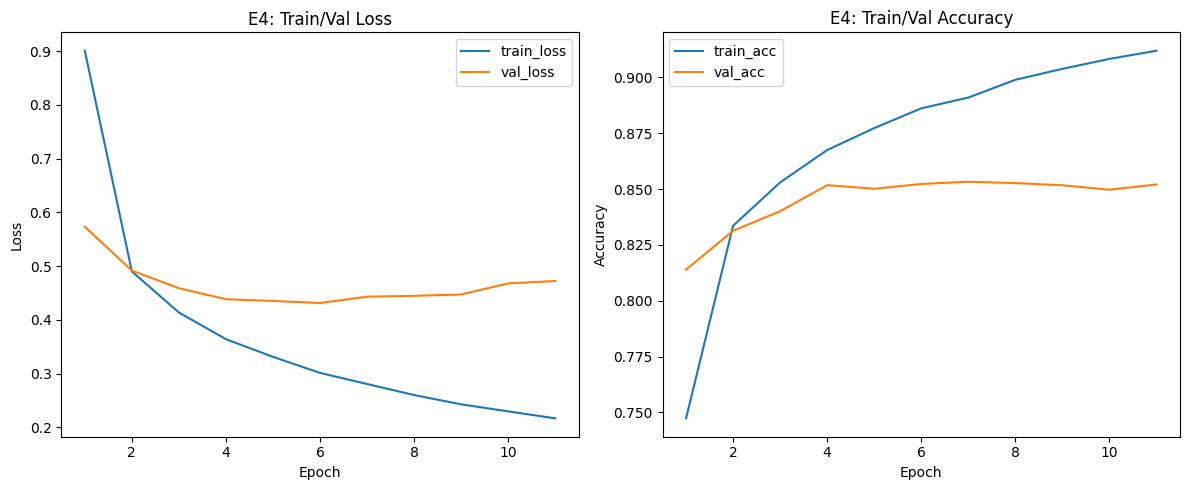

Saved: artifacts\figures\curves_best.png


In [23]:
# ШАГ 30. Строим графики для лучшего прогона E4
history = E4["history"]
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# График loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="train_loss")
plt.plot(epochs_range, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E4: Train/Val Loss")
plt.legend()

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="train_acc")
plt.plot(epochs_range, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E4: Train/Val Accuracy")
plt.legend()

plt.tight_layout()

curves_best_path = FIGURES_DIR / "curves_best.png"
plt.savefig(curves_best_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", curves_best_path)

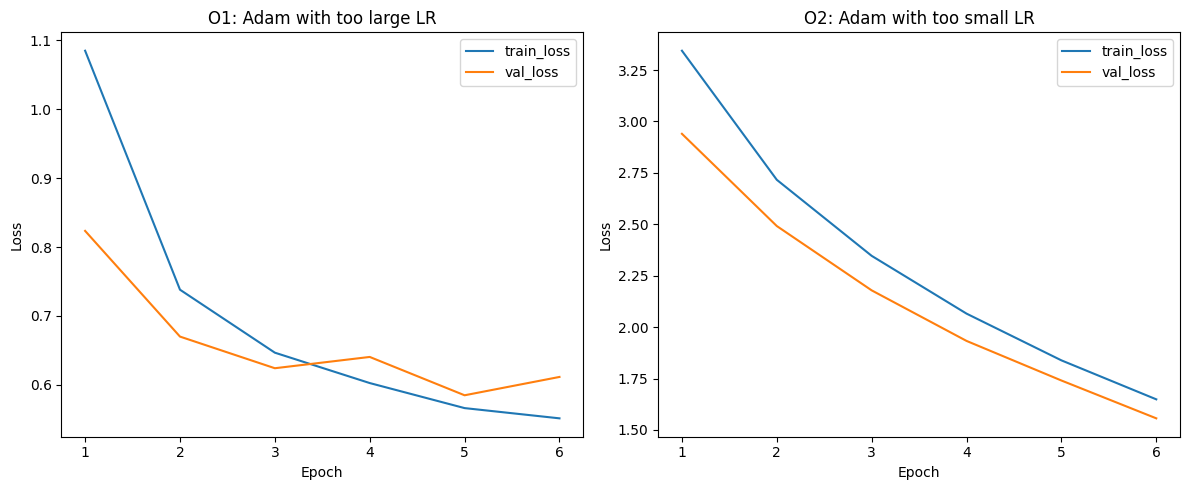

Saved: artifacts\figures\curves_lr_extremes.png


In [24]:
# ШАГ 31. Строим графики для O1 и O2, чтобы показать плохой learning rate
o1_history = O1["history"]
o2_history = O2["history"]

o1_epochs = range(1, len(o1_history["train_loss"]) + 1)
o2_epochs = range(1, len(o2_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# O1: слишком большой lr
plt.subplot(1, 2, 1)
plt.plot(o1_epochs, o1_history["train_loss"], label="train_loss")
plt.plot(o1_epochs, o1_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("O1: Adam with too large LR")
plt.legend()

# O2: слишком маленький lr
plt.subplot(1, 2, 2)
plt.plot(o2_epochs, o2_history["train_loss"], label="train_loss")
plt.plot(o2_epochs, o2_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("O2: Adam with too small LR")
plt.legend()

plt.tight_layout()

curves_lr_path = FIGURES_DIR / "curves_lr_extremes.png"
plt.savefig(curves_lr_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", curves_lr_path)

In [25]:
# ШАГ 32. Делаем финальную оценку лучшей модели на test ровно один раз
final_model = MLP(
    input_dim=28*28,
    num_classes=47,
    hidden_sizes=E4["config"]["hidden_sizes"],
    dropout=E4["config"]["dropout"],
    use_batchnorm=E4["config"]["use_batchnorm"]
).to(device)

# ШАГ 33. Загружаем лучшие веса
final_model.load_state_dict(torch.load(best_model_path, map_location=device))

# ШАГ 34. Считаем test loss и test accuracy
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(final_model, test_loader, criterion, device)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4563
Final test accuracy: 0.8513


In [26]:
# ШАГ 35. Финальная таблица результатов
runs_df.sort_values("experiment_id")

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00100,0.0,0.0000,12,0.843972,0.480034
1,E2,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.3,...",Adam,0.00100,0.0,0.0000,12,0.834220,0.489990
2,E3,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00100,0.0,0.0000,12,0.855275,0.428932
3,E4,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00100,0.0,0.0000,11,0.853280,0.443296
4,O1,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.10000,0.0,0.0000,6,0.806294,0.611536
5,O2,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",Adam,0.00001,0.0,0.0000,6,0.703901,1.556252
6,O3,EMNIST,42,"hidden=[512, 256, 128], act=ReLU, dropout=0.0,...",SGD,0.01000,0.9,0.0001,12,0.853324,0.449410


In [27]:
# ШАГ 36. Краткие выводы по экспериментам

print("Выводы:")
print("1. В части A лучший результат по val_accuracy показал эксперимент E3 (BatchNorm): 0.855275.")
print("2. Эксперимент E2 с Dropout показал результат ниже базового E1, поэтому в данном конфиге Dropout не дал улучшения.")
print("3. Эксперимент E4 был построен на лучшей архитектуре из E2/E3 с EarlyStopping и обучался 11 эпох.")
print("4. Несмотря на использование EarlyStopping, E4 немного уступил E3 по best_val_accuracy: 0.853280 против 0.855275.")
print("5. Это означает, что BatchNorm оказался наиболее полезной регуляризацией в данной домашней работе.")
print("6. В O1 слишком большой learning rate (Adam, lr=1e-1) привёл к менее стабильному обучению и более слабому качеству по сравнению с нормальным lr=1e-3.")
print("7. В O2 слишком маленький learning rate (Adam, lr=1e-5) заметно замедлил обучение: best_val_accuracy = 0.703901, best_val_loss = 1.556252.")
print("8. В O3 оптимизатор SGD+momentum+weight_decay показал результат 0.853324, что очень близко к лучшим результатам Adam.")
print("9. Следовательно, для EMNIST MLP с BatchNorm является удачной базовой архитектурой, а слишком большие и слишком маленькие значения learning rate ухудшают обучение.")

Выводы:
1. В части A лучший результат по val_accuracy показал эксперимент E3 (BatchNorm): 0.855275.
2. Эксперимент E2 с Dropout показал результат ниже базового E1, поэтому в данном конфиге Dropout не дал улучшения.
3. Эксперимент E4 был построен на лучшей архитектуре из E2/E3 с EarlyStopping и обучался 11 эпох.
4. Несмотря на использование EarlyStopping, E4 немного уступил E3 по best_val_accuracy: 0.853280 против 0.855275.
5. Это означает, что BatchNorm оказался наиболее полезной регуляризацией в данной домашней работе.
6. В O1 слишком большой learning rate (Adam, lr=1e-1) привёл к менее стабильному обучению и более слабому качеству по сравнению с нормальным lr=1e-3.
7. В O2 слишком маленький learning rate (Adam, lr=1e-5) заметно замедлил обучение: best_val_accuracy = 0.703901, best_val_loss = 1.556252.
8. В O3 оптимизатор SGD+momentum+weight_decay показал результат 0.853324, что очень близко к лучшим результатам Adam.
9. Следовательно, для EMNIST MLP с BatchNorm является удачной базов